<a href="https://colab.research.google.com/github/Roshanreddy03/Tips-Data-cleaning/blob/main/Tips_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tips Data cleaning

Load the data set

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")

print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


**Bar chart**

Matplotlib

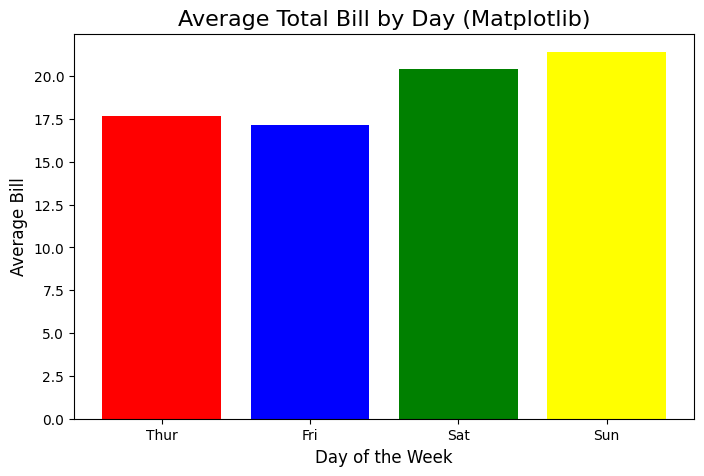

In [ ]:
# calculating average bill per day
avg_bill = tips.groupby('day', observed=False)['total_bill'].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_bill.index, avg_bill.values, color=['red','blue','green','yellow'])

plt.title('Average Total Bill by Day (Matplotlib)', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Bill', fontsize=12)

plt.show()

Seaborn

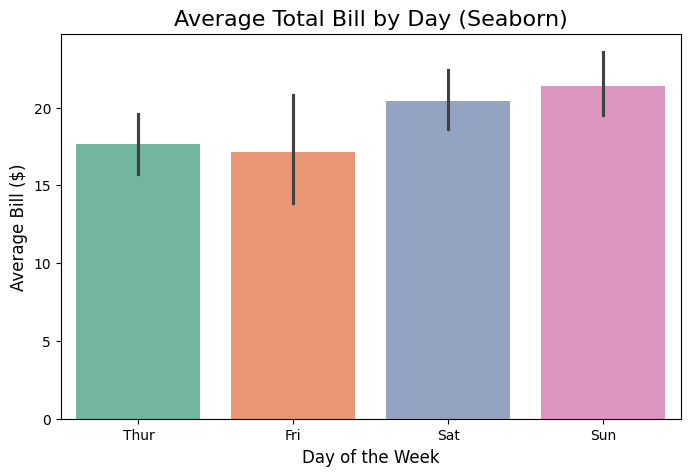

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tips, x='day', y='total_bill',hue='day', palette='Set2', legend=False)
# hue tells seaborn that the colour(palette) should be mapped to the 'day'column

plt.title('Average Total Bill by Day (Seaborn)', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Bill ($)', fontsize=12)

plt.show()

**Histogram**

Matplotlib

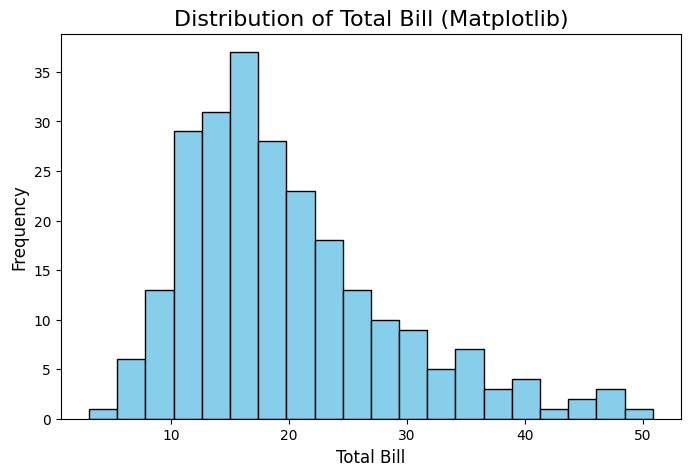

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(tips['total_bill'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Total Bill (Matplotlib)', fontsize=16)
plt.xlabel('Total Bill', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

Seaborn

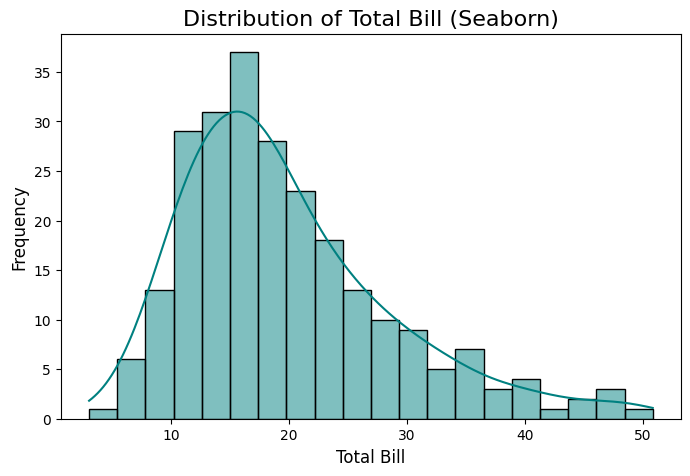

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', bins=20, color='teal', kde=True)

plt.title('Distribution of Total Bill (Seaborn)', fontsize=16)
plt.xlabel('Total Bill', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

**Box plot**

Matplotlib

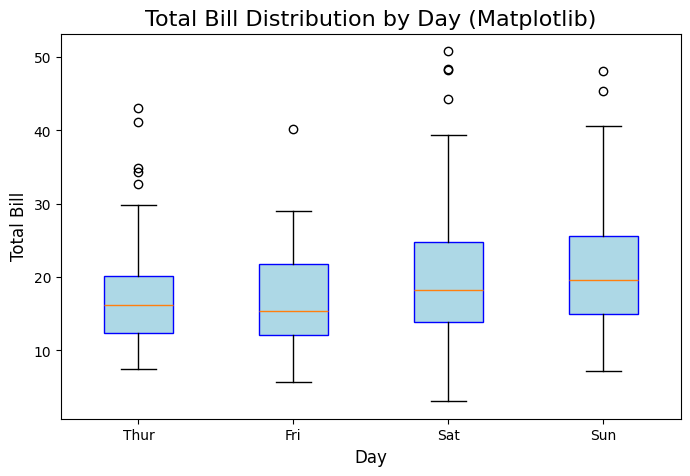

In [ ]:
# Preparing data for matplotlib boxplot (needs a list of arrays)
days = tips['day'].cat.categories
data_to_plot = [tips[tips['day'] == day]['total_bill'] for day in days]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=days, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'))

plt.title('Total Bill Distribution by Day (Matplotlib)', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Bill', fontsize=12)

plt.show()

Seaborn

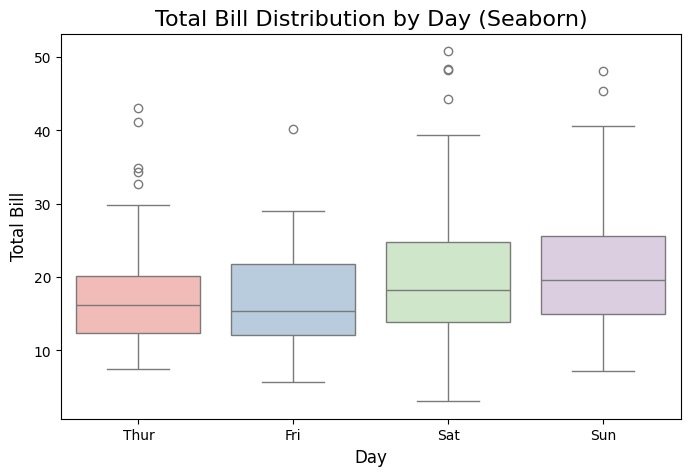

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x='day', y='total_bill',hue='day', palette='Pastel1')

plt.title('Total Bill Distribution by Day (Seaborn)', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Bill', fontsize=12)

plt.show()

**Scatter Plot**

Matplotlib

Chart saved as 'matplotlib_scatter.png'


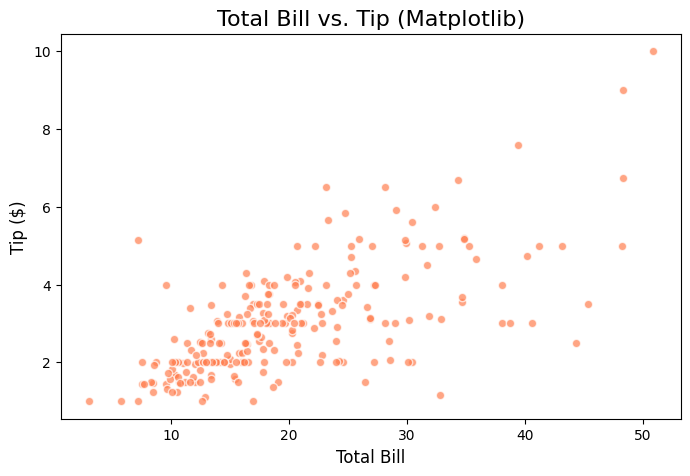

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(tips['total_bill'], tips['tip'], color='coral', alpha=0.7, edgecolors='w')

plt.title('Total Bill vs. Tip (Matplotlib)', fontsize=16)
plt.xlabel('Total Bill', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)

# Saving this chart as a PNG file.
plt.savefig('matplotlib_scatter.png', dpi=300, bbox_inches='tight')
print("Chart saved as 'matplotlib_scatter.png'")

plt.show()

Seaborn

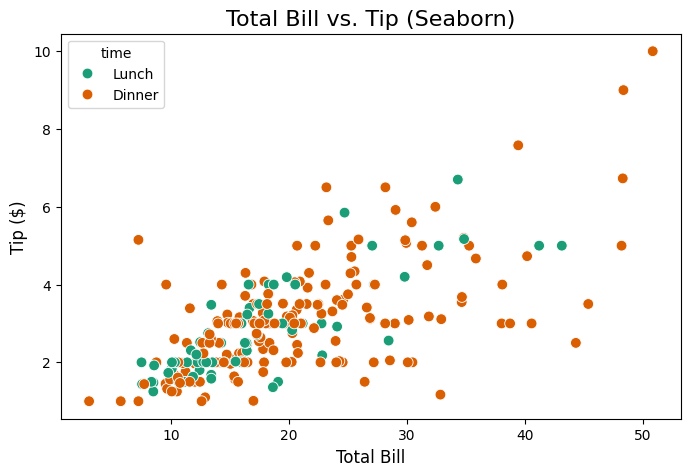

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', palette='Dark2', s=60)

plt.title('Total Bill vs. Tip (Seaborn)', fontsize=16)
plt.xlabel('Total Bill', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)

plt.show()

**Heatmap of Correlations**

Calculate the Correlation Matrix:

In [ ]:
# Numeric columns to find correlations
numeric_tips = tips.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_tips.corr()

Matplotlib

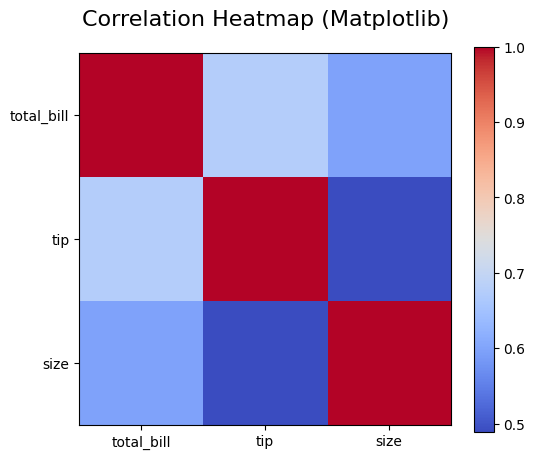

In [ ]:
plt.figure(figsize=(6, 5))
cax = plt.imshow(correlation_matrix, cmap='coolwarm')
plt.colorbar(cax)

# Set ticks and labels
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, fontsize=10)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, fontsize=10)

plt.title('Correlation Heatmap (Matplotlib)', fontsize=16, pad=20)

plt.show()

Seaborn

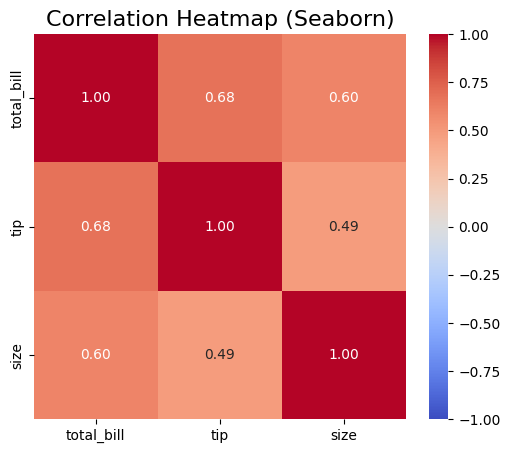

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title('Correlation Heatmap (Seaborn)', fontsize=16)

plt.show()